# **Bibliotecas Utilizadas e Importação do Banco de Dados**

In [6]:
from wordcloud import WordCloud
from collections import Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# **Funções de Análise Exploratória**

In [7]:
def analise_inicial(df):
  print("\nInformações Gerais da Tabela")
  print(df.info())

  print("\nTipo das variáveis")
  display(df.dtypes)

  print("\nPrimeiras 10 Linhas")
  display(df.head(10))

  print("\nUltimas 10 Linhas")
  display(df.tail(10))

  print("\nEstatísticas Descritivas")
  display(df.describe())

  print("\nObservação das Colunas")
  print(df.columns)

  print("\nQuantidade de Linhas e Colunas")
  print(df.shape)
  print()

In [8]:
def verificacao_nulo(df):
  print("Verificação de Números Nulos")
  print(df.isnull().sum())

  print("\nVerificação de Duplicatas")
  print(f"{df.duplicated().sum()}\n")

In [9]:
def classificacao_sentimento(valor):
  if valor < -0.6:
    return 'Muito negativo'
  elif valor >= -0.6 and valor < -0.2:
    return 'Negativo'
  elif valor >= -0.2 and valor < 0.2:
    return 'Neutro'
  elif valor >= 0.2 and valor <= 0.6:
    return 'Positivo'
  elif valor > 0.6:
    return 'Muito Positivo'
  else:
    return 'Default'

In [10]:
def exploracao_do_banco(df):
  analise_inicial(df)
  verificacao_nulo(df)

- Criar uma função com dicionarios auxiliares

# **Visualização Das Tabelas do Banco de Dados**

In [11]:
df_avaliacoes = pd.read_csv('avaliacoes.csv')
df_vendedores = pd.read_csv('vendedores.csv')
df_produtos = pd.read_csv('produtos.csv')
df_pedidos = pd.read_csv('pedidos.csv')
df_itens_pedidos = pd.read_csv('itens_pedidos.csv')
df_geolocalizacao = pd.read_csv('geolocalizacao.csv')
df_clientes = pd.read_csv('clientes.csv')
df_pagamentos = pd.read_csv('pagamentos.csv')
df_auxiliar = pd.read_csv('tabela_auxiliar.csv')

In [19]:
def dicionario_dados(df):
    return pd.DataFrame({
        'Coluna': df.columns,
        'Tipo': df.dtypes.values,
        'Valores Nulos': df.isnull().sum().values,
        'Duplicados': df.duplicated().sum()
    })

dicionario_dados(df_avaliacoes)

,Coluna,Tipo,Valores Nulos,Duplicados
0,review_id,object,0,0
1,order_id,object,0,0
2,review_score,int64,0,0
3,review_comment_title,object,87656,0
4,review_comment_message,object,58247,0
5,review_creation_date,object,0,0
6,review_answer_timestamp,object,0,0


In [27]:
pedidos = df_pedidos.copy()
avaliacoes = df_avaliacoes.copy()
clientes = df_clientes.copy()
pagamentos = df_pagamentos.copy()
itens = df_itens_pedidos.copy()
produtos = df_produtos.copy()
vendedores = df_vendedores.copy()

In [35]:
df_completo = (
    pedidos

    .merge(
        avaliacoes,
        on='order_id',
        how='left'
    )

    .merge(
        clientes,
        on='customer_id',
        how='left'
    )

    .merge(
        pagamentos,
        on='order_id',
        how='left'
    )

    .merge(
        itens,
        on='order_id',
        how='left'
    )

    .merge(
        produtos,
        on='product_id',
        how='left'
    )

    .merge(
        vendedores,
        on='seller_id',
        how='left',
        suffixes=('', '_seller')
    )

)

In [42]:
print(df_completo.shape)

(119143, 39)


In [38]:
df_completo.duplicated().sum()

np.int64(0)

In [40]:
df_completo.isnull().sum().sort_values(ascending=False)

review_comment_title             105154
review_comment_message            68898
order_delivered_customer_date      3421
product_name_lenght                2542
product_description_lenght         2542
product_category_name              2542
product_photos_qty                 2542
order_delivered_carrier_date       2086
review_answer_timestamp             997
review_score                        997
review_id                           997
review_creation_date                997
product_width_cm                    853
product_length_cm                   853
product_height_cm                   853
product_weight_g                    853
product_id                          833
shipping_limit_date                 833
price                               833
seller_city                         833
seller_id                           833
order_item_id                       833
freight_value                       833
seller_state                        833
seller_zip_code_prefix              833


In [41]:
df_sem_nulos = df_completo.copy()

In [63]:
df_completo['tamanho_comentario'] = (
    df_completo['review_comment_message']
    .fillna('')
    .str.len()
)

In [64]:
df_filtrado = df_completo[
    df_completo['review_comment_message'].notnull()
].copy()

In [66]:
dados = list(
    zip(
        df_filtrado['review_comment_message'],
        df_filtrado['tamanho_comentario']
    )
)

In [67]:
def merge_sort_tuplas(lista):

    if len(lista) <= 1:
        return lista

    meio = len(lista) // 2

    esquerda = merge_sort_tuplas(lista[:meio])
    direita = merge_sort_tuplas(lista[meio:])

    return merge_tuplas(esquerda, direita)

In [68]:
def merge_tuplas(esquerda, direita):

    resultado = []

    i = 0
    j = 0

    while i < len(esquerda) and j < len(direita):

        if esquerda[i][1] < direita[j][1]:

            resultado.append(esquerda[i])
            i += 1

        else:

            resultado.append(direita[j])
            j += 1

    resultado.extend(esquerda[i:])
    resultado.extend(direita[j:])

    return resultado

In [69]:
ordenado = merge_sort_tuplas(dados)

In [70]:
df_merge_sort = pd.DataFrame(
    ordenado,
    columns=[
        'comentario',
        'tamanho'
    ]
)

In [73]:
display(df_merge_sort.tail(20))

,comentario,tamanho
119123,Não Montei ele ainda mais pelo que conferi est...,204
119124,assim que fiz o pedido observei que tinha pedi...,204
119125,Na minha compra realizada em 20/09/17 a loja t...,204
119126,Comprei dois itens semelhantes (cartuchos de t...,204
119127,A targaryen não é de confiança não entregou a ...,204
119128,Recebi a mercadoria errada.\r\nComprei o chuve...,204
119129,A EMPRESA FAZ PROPAGANDA ENGANOSA EM SEU SITE....,204
119130,O produto cumpre totalmente com o que o fabric...,204
119131,Fornecedor targaryen me mandou um massageador ...,204
119132,"Recebi o produto, mas a embalagem e falta do s...",204


In [74]:
for i, row in df_merge_sort.head(10).iterrows():

    print(f"Tamanho: {row['tamanho']}")
    print(f"Comentário: {row['comentario']}")
    print('-' * 100)

Tamanho: 1
Comentário: .
----------------------------------------------------------------------------------------------------
Tamanho: 1
Comentário: .
----------------------------------------------------------------------------------------------------
Tamanho: 1
Comentário: .
----------------------------------------------------------------------------------------------------
Tamanho: 1
Comentário: .
----------------------------------------------------------------------------------------------------
Tamanho: 1
Comentário: .
----------------------------------------------------------------------------------------------------
Tamanho: 1
Comentário: .
----------------------------------------------------------------------------------------------------
Tamanho: 1
Comentário: .
----------------------------------------------------------------------------------------------------
Tamanho: 1
Comentário: S
---------------------------------------------------------------------------------------------

In [43]:
df_completo['review_comment_message'] = (
    df_completo['review_comment_message']
    .fillna('Sem comentário')
)

In [44]:
df_completo['review_comment_title'] = (
    df_completo['review_comment_title']
    .fillna('Sem título')
)

In [45]:
df_completo['product_category_name'] = (
    df_completo['product_category_name']
    .fillna('Categoria desconhecida')
)

In [ ]:
df_completo.select_dtypes(include=['int64', 'float64']).columns

In [ ]:
df_completo.select_dtypes(include=['object']).columns

In [ ]:
df_completo.select_dtypes(include=['datetime64']).columns

In [46]:
comentarios = (
    df_completo['review_comment_message']
    .dropna()
    .tolist()
)

In [47]:
def merge_sort(lista):

    if len(lista) <= 1:
        return lista

    meio = len(lista) // 2

    esquerda = merge_sort(lista[:meio])
    direita = merge_sort(lista[meio:])

    return merge(esquerda, direita)

In [48]:
def merge(esquerda, direita):

    resultado = []

    i = 0
    j = 0

    while i < len(esquerda) and j < len(direita):

        if esquerda[i] < direita[j]:
            resultado.append(esquerda[i])
            i += 1

        else:
            resultado.append(direita[j])
            j += 1

    resultado.extend(esquerda[i:])
    resultado.extend(direita[j:])

    return resultado

In [49]:
comentarios_ordenados = merge_sort(comentarios)

In [50]:
comentarios_ordenados[:20]

['\r\n',
 '\r\n',
 '\r\n',
 '\r\n',
 '\r\n',
 '\r\n',
 '\r\n',
 '\r\n',
 '\r\n',
 '\r\n',
 '\r\n',
 '\r\n',
 '\r\n',
 '\r\n',
 '\r\n',
 '\r\n',
 '\r\n',
 '\r\n',
 '\r\n\r\n',
 '\r\n\r\n']

In [51]:
def merge_sort_tamanho(lista):

    if len(lista) <= 1:
        return lista

    meio = len(lista) // 2

    esquerda = merge_sort_tamanho(lista[:meio])
    direita = merge_sort_tamanho(lista[meio:])

    return merge_tamanho(esquerda, direita)

In [52]:
def merge_tamanho(esquerda, direita):

    resultado = []

    i = 0
    j = 0

    while i < len(esquerda) and j < len(direita):

        if len(esquerda[i]) < len(direita[j]):
            resultado.append(esquerda[i])
            i += 1

        else:
            resultado.append(direita[j])
            j += 1

    resultado.extend(esquerda[i:])
    resultado.extend(direita[j:])

    return resultado

In [53]:
comentarios_tamanho = merge_sort_tamanho(comentarios)

In [54]:
comentarios_tamanho[-10:]

['Recebi o produto, mas a embalagem e falta do selo de autenticidade não me deixaram confortável.Solicitei a troca e enviei, cancelaram a troca já com os produtos a caminho da targaryen exijo o estorno do $',
 'RECEBI UM PRODUTO F-A-L-S-I-F-I-C-A-D-O. Ñ SABE NEM DISFARÇAR. TOTALMENTE DIFERENTE DO ORIGINAL. DEMORA PARA RESOLVER MEU PROBLEMA, NÃO CONSIGO TROCAR NEM PEDIR REEMBOLSO. NAO COMPREM COM targaryen NUNCA!',
 'Parabéns , ,estou satisfeita com a loja e com o produto ,\r\nEu sou cliente do baratheon a muitos anos e não tenho que reclamar , sempre foi muito bem atendida ,\r\nParabéns a targaryen e Parabéns baratheon. ',
 'A empresa terceira targaryen não é confiavel, eles vedem produtos que não tem, você paga, espera, não recebe e depois tem que correr atras de reembolso.\r\nNão recomendo de jeito nenhum está empresa, e a su',
 'Parabéns ,o produto tira rico da empresa targaryen chegou normalmente, mas um segundo produto que também comprei não chegou até o momento na minha residênci

In [55]:
df_completo['tamanho_comentario'] = (
    df_completo['review_comment_message']
    .str.len()
)

In [56]:
dados = list(
    zip(
        df_completo['review_comment_message'],
        df_completo['tamanho_comentario']
    )
)

In [57]:
def merge_sort_tuplas(lista):

    if len(lista) <= 1:
        return lista

    meio = len(lista) // 2

    esquerda = merge_sort_tuplas(lista[:meio])
    direita = merge_sort_tuplas(lista[meio:])

    return merge_tuplas(esquerda, direita)

In [58]:
def merge_tuplas(esquerda, direita):

    resultado = []

    i = 0
    j = 0

    while i < len(esquerda) and j < len(direita):

        if esquerda[i][1] < direita[j][1]:

            resultado.append(esquerda[i])
            i += 1

        else:

            resultado.append(direita[j])
            j += 1

    resultado.extend(esquerda[i:])
    resultado.extend(direita[j:])

    return resultado

In [59]:
ordenado = merge_sort_tuplas(dados)

In [60]:
ordenado[:10]

[('.', 1),
 ('.', 1),
 ('.', 1),
 ('.', 1),
 ('.', 1),
 ('.', 1),
 ('.', 1),
 ('S', 1),
 ('s', 1),
 ('s', 1)]

In [62]:
for comentario in comentarios_ordenados[:20]:
    print(comentario)
    print('-' * 100)



----------------------------------------------------------------------------------------------------


----------------------------------------------------------------------------------------------------


----------------------------------------------------------------------------------------------------


----------------------------------------------------------------------------------------------------


----------------------------------------------------------------------------------------------------


----------------------------------------------------------------------------------------------------


----------------------------------------------------------------------------------------------------


----------------------------------------------------------------------------------------------------


----------------------------------------------------------------------------------------------------


-----------------------------------------------------------------------

In [26]:
colunas_datas = [
    'review_creation_date',
    'review_answer_timestamp'
]

df_avaliacoes_tratado = df_avaliacoes.copy()

for col in colunas_datas:
    df_avaliacoes_tratado[col] = pd.to_datetime(df_avaliacoes_tratado[col])

# **Análise Sentimental**

In [15]:
df_produtos_copia = df_produtos.copy()

##  **Biblioteca Vader**

In [16]:
df_avaliacoes_copia = df_avaliacoes.copy()

In [17]:
# !pip install vaderSentiment

In [18]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

sid = SentimentIntensityAnalyzer()
df_avaliacoes_copia['review_comment_message'] = (
df_avaliacoes_copia['review_comment_message'].fillna('')
)

def calcular_sentimento(texto):
  if texto.strip() == '':
    return 0.0
  return sid.polarity_scores(texto)['compound']

df_avaliacoes_copia['pontuacao_vader'] = (
  df_avaliacoes_copia['review_comment_message'].apply(calcular_sentimento)
)

ModuleNotFoundError: No module named 'vaderSentiment'

In [ ]:
df_avaliacoes_copia.loc[:, ['review_comment_message', 'pontuacao_vader', 'review_score']]

,review_comment_message,pontuacao_vader,review_score
0,,0.0000,4
1,,0.0000,5
2,,0.0000,5
3,Recebi bem antes do prazo estipulado.,0.0000,5
4,Parabéns lojas lannister adorei comprar pela I...,0.0000,5
...,...,...,...
99219,,0.0000,5
99220,,0.0000,5
99221,"Excelente mochila, entrega super rápida. Super...",0.8439,5
99222,,0.0000,4


## **Biblioteca LeIA**

In [ ]:
#!pip install leia-br

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.0/130.0 kB 3.6 MB/s eta 0:00:00


In [ ]:
from LeIA import SentimentIntensityAnalyzer

sid = SentimentIntensityAnalyzer()

df_avaliacoes_copia['review_comment_message'] = (
df_avaliacoes_copia['review_comment_message'].fillna ('')
)

def calcular_sentimentos(texto):
  if texto.strip() == '':
    return 0.0
  return sid.polarity_scores(texto)['compound']

df_avaliacoes_copia['pontuacao_leia'] = (
df_avaliacoes_copia['review_comment_message'].apply(calcular_sentimentos)
 )


In [ ]:
df_avaliacoes_copia.loc[:, ['review_score', 'review_comment_message', 'pontuacao_vader', 'pontuacao_leia']]

,review_score,review_comment_message,pontuacao_vader,pontuacao_leia
0,4,,0.0000,0.0000
1,5,,0.0000,0.0000
2,5,,0.0000,0.0000
3,5,Recebi bem antes do prazo estipulado.,0.0000,0.2732
4,5,Parabéns lojas lannister adorei comprar pela I...,0.0000,0.9413
...,...,...,...,...
99219,5,,0.0000,0.0000
99220,5,,0.0000,0.0000
99221,5,"Excelente mochila, entrega super rápida. Super...",0.8439,0.9402
99222,4,,0.0000,0.0000


In [ ]:
def classificacao_sentimento(valor, nome):
  condicoes = [
    (df_avaliacoes_copia[valor] < -0.6),
    (df_avaliacoes_copia[valor] >= -0.6) & (df_avaliacoes_copia[valor] < -0.2),
    (df_avaliacoes_copia[valor] >= -0.2) & (df_avaliacoes_copia[valor] < 0.2),
    (df_avaliacoes_copia[valor] >= 0.2) & (df_avaliacoes_copia[valor] <= 0.6),
    (df_avaliacoes_copia[valor] > 0.6)
]

  escolhas = ['Muito Negativo', 'Negativo', 'Neutro', 'Positivo', 'Muito Positivo']
  df_avaliacoes_copia[nome] = np.select(condicoes, escolhas, default='Outro')

In [ ]:
classificacao_sentimento('pontuacao_leia', 'classificacao_leia')

In [ ]:
classificacao_sentimento('pontuacao_vader', 'classificacao_vader')

In [ ]:
df_avaliacoes_copia.loc[:, ['review_score', 'review_comment_message', 'pontuacao_vader', 'classificacao_vader', 'pontuacao_leia', 'classificacao_leia']]

,review_score,review_comment_message,pontuacao_vader,classificacao_vader,pontuacao_leia,classificacao_leia
0,4,,0.0000,Neutro,0.0000,Neutro
1,5,,0.0000,Neutro,0.0000,Neutro
2,5,,0.0000,Neutro,0.0000,Neutro
3,5,Recebi bem antes do prazo estipulado.,0.0000,Neutro,0.2732,Positivo
4,5,Parabéns lojas lannister adorei comprar pela I...,0.0000,Neutro,0.9413,Muito Positivo
...,...,...,...,...,...,...
99219,5,,0.0000,Neutro,0.0000,Neutro
99220,5,,0.0000,Neutro,0.0000,Neutro
99221,5,"Excelente mochila, entrega super rápida. Super...",0.8439,Muito Positivo,0.9402,Muito Positivo
99222,4,,0.0000,Neutro,0.0000,Neutro


## **Biblioteca Transformers**

In [ ]:
from transformers import pipeline
classificador = pipeline('sentiment-analysis')

def obter_sentimento(texto):
  resultado = classificador(texto)[0]
  return f"{resultado['label']} (Confiança: {resultado['score']:.2f})"
df_avaliacoes_copia['resultado'] = df_avaliacoes_copia['review_comment_message'].apply(obter_sentimento)

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

##### Fazer futuramente!

## **Gráficos**

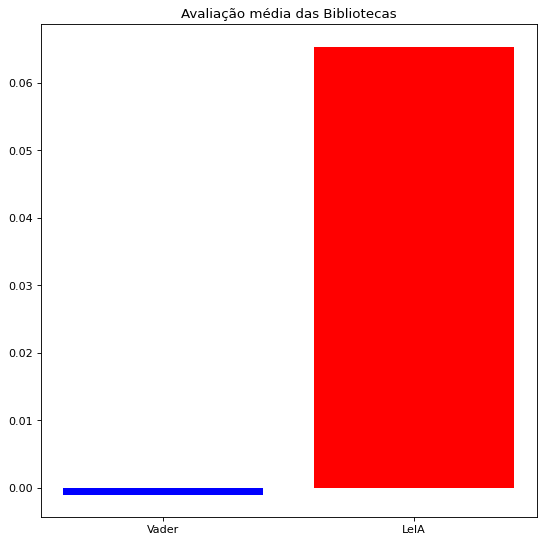

In [ ]:
media_vader = df_avaliacoes_copia['pontuacao_vader'].mean()
media_leia = df_avaliacoes_copia['pontuacao_leia'].mean()
categorias = ['Vader', 'LeIA']
valores = [media_vader, media_leia]

plt.figure(figsize=(8,8), dpi=80)
plt.bar(categorias, valores, color=["blue", "red"])
plt.title("Avaliação média das Bibliotecas")
plt.show()

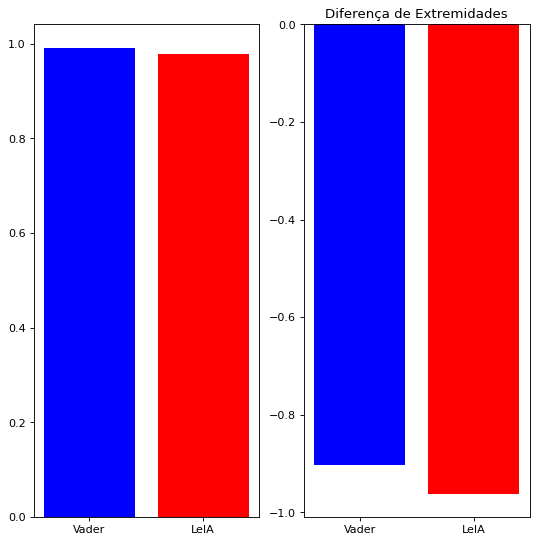

In [ ]:
maior_vader = df_avaliacoes_copia['pontuacao_vader'].max()
maior_leia = df_avaliacoes_copia['pontuacao_leia'].max()
menor_vader = df_avaliacoes_copia['pontuacao_vader'].min()
menor_leia = df_avaliacoes_copia['pontuacao_leia'].min()

plt.figure(figsize=(8,8), dpi=80)
categorias = ['Vader', 'LeIA']
valores = [maior_vader, maior_leia]
plt.subplot(1,2,1)
plt.bar(categorias, valores, color=["blue", "red"])

plt.subplot(1,2,2)
valores2 = [menor_vader, menor_leia]
plt.bar(categorias, valores2, color=["blue", "red"])
plt.title("Diferença de Extremidades")
plt.show()

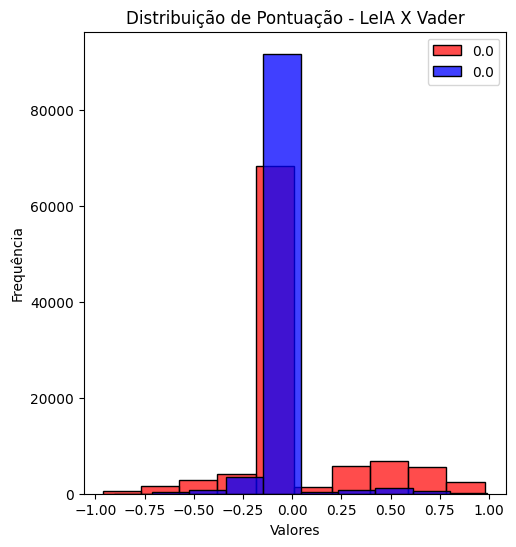

In [ ]:
plt.figure(figsize=(12,6))

# kde = Uma curva contínua suavizada que aproxima a distribuição subjacente aos dados
plt.subplot(1,2,1)
sns.histplot(df_avaliacoes_copia['pontuacao_leia'], bins=10, edgecolor='black', color='red', alpha=0.7)
plt.title('Distribuição de Pontuação - LeIA', fontsize=14)
plt.xlabel('Valores', fontsize=12)
plt.ylabel('Frequência', fontsize=12)

plt.subplot(1,2,1)
sns.histplot(df_avaliacoes_copia['pontuacao_vader'], bins=10, edgecolor='black', color='blue')
plt.title('Distribuição de Pontuação - LeIA X Vader', fontsize=12)
plt.xlabel('Valores', fontsize=10)
plt.ylabel('Frequência', fontsize=10)
plt.legend(labels=df_avaliacoes_copia['pontuacao_leia'], loc='upper right')
plt.show()

# **Tratamentos Iniciais**


## **Visualização das Variavéis**

### **Tabela de Produtos**

In [ ]:
df_produtos.dtypes

- Selecionar todas as colunas da tabela que possuem o mesmo tipo de variável para análise

In [ ]:
df_produtos.select_dtypes(include="float64")

- Tratamento dos tipos das colunas

In [ ]:
df_produtos_reduzido["product_category_name"] = df_produtos_reduzido["product_category_name"].astype("category")

In [ ]:
df_produtos_reduzido["product_id"] = df_produtos_reduzido["product_id"].astype(str)

In [ ]:
df_produtos_reduzido.dtypes

#### **Tabela de Produtos - Valores Nulos**

In [ ]:
df_produtos_reduzido.isnull().sum()

- Identificação de Nulos na tabela através da observação de True para nulos e False para valores válidos

In [ ]:
df_produtos_reduzido.isna() # OU df_produtos_reduzido.isnull() --- Fazem a mesma coisa!

- Contagem do total de nulos da tabela

In [ ]:
df_produtos_reduzido.isnull().sum().sum()

- Filtrar linhas com nulos

In [ ]:
df_produtos_reduzido[df_produtos_reduzido.isnull().any(axis=1)]

- Remover linhas com nulos

In [ ]:
df_produtos_reduzido = df_produtos_reduzido.dropna(subset=['product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty'])

In [ ]:
df_produtos_reduzido = df_produtos_reduzido.dropna(subset=['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm'])

- Verificação de remoção

In [ ]:
df_produtos_reduzido.isnull().sum()

### **Tabela de avaliações**

In [ ]:
df_avaliacoes.dtypes

In [ ]:
df_avaliacoes.select_dtypes(include='object')

In [ ]:
df_avaliacoes_reduzido["review_id"] = df_avaliacoes_reduzido["review_id"].astype(str)

In [ ]:
df_avaliacoes_reduzido["order_id"] = df_avaliacoes_reduzido["order_id"].astype(str)

In [ ]:
df_avaliacoes_reduzido["review_comment_title"] = df_avaliacoes_reduzido["review_comment_title"].astype(str)

In [ ]:
df_avaliacoes_reduzido["review_comment_message"] = df_avaliacoes_reduzido["review_comment_message"].astype(str)

In [ ]:
df_avaliacoes_reduzido['review_creation_date'] = pd.to_datetime(df_avaliacoes_reduzido['review_creation_date'])

In [ ]:
df_avaliacoes_reduzido['review_answer_timestamp'] = pd.to_datetime(df_avaliacoes_reduzido['review_answer_timestamp'])

In [ ]:
df_avaliacoes_reduzido.dtypes

#### **Tabela de Avaliações - Valores Nulos**

In [ ]:
df_avaliacoes.isnull().sum()

### **Tabela de Pedidos**

In [ ]:
df_pedidos_reduzido = df_pedidos.copy()

In [ ]:
df_pedidos_reduzido.dtypes

In [ ]:
df_pedidos_reduzido.isnull().sum()

## **Duplicatas**

### **Tabela de Geolocalização**

In [ ]:
df_geolocalizacao_reduzido = df_geolocalizacao.drop_duplicates().copy()
df_geolocalizacao_reduzido.duplicated().sum()

# **Análise de Sentimento**

In [ ]:
df_avaliacoes_reduzido['tamanho'] = df_avaliacoes_reduzido['review_comment_message'].str.len()
display(df_avaliacoes_reduzido['tamanho'], df_avaliacoes_reduzido['review_score'])

- Garantir que a coluna comentários não tenha valores nulos

In [ ]:
df_avaliacoes_reduzido = df_avaliacoes_reduzido.dropna(subset=['review_comment_message'])

- Contar quantos valores estão em maiúsculas

In [ ]:
df_avaliacoes_reduzido['review_comment_message'].str.isupper().sum()

- Contar quantos valores estão em minúsculas

In [ ]:
df_avaliacoes_reduzido['review_comment_message'].str.islower().sum()

- Células que contém apenas espaços!

In [ ]:
df_avaliacoes_reduzido['review_comment_message'].str.isspace().sum()

- Identificar emojis

In [ ]:
regex_emojis = '[^\w\s,.]'
tem_emoji = df_avaliacoes_reduzido['review_comment_message'].str.contains(regex_emojis, regex=True, na=False)
print('Quantidade de Emojis:', tem_emoji.sum())


# ***Anotações - Desconsiderar***

- Trabalho a ser realizado:
  - Padronizar textos
  - Verificação de Integridade
  - Análise de Sentimento
- Trabalho realizado:
  - Tabelas com os tipos de variáveis tratados: Produtos e Avaliações
  

In [ ]:
# for nome, df in tabelas.items():
  # analise_inicial(nome, df)

In [ ]:
'''for nome, df in tabelas.items():
  print("Tabela:", nome)
  verificacao_nulo(nome, df)'''